# **🏎️ Building a Linear Regression Model - Driver Position**
The dataset consists of all information on the Formula 1 races, drivers, constructors, qualifying, circuits, lap times, pit stops, championships from 1950 till the latest 2024 season.

## **Predicting Lap Time Degradation (Tire Wear)**

Instead of predicting an entire race result, model how performance drops over time.

* **Target Variable ($y$):** Lap Time (or time delta from average/baseline)
* **Key Features ($X$):**
* Tire Age (laps on current set)
* Fuel Load (estimated via $Total Laps - Current Lap$)
* Track Temperature
* Compound Type (Categorical / One-Hot Encoded)


**Why Linear Regression Works:**
- **Strong Linear Relationships**: Starting position (grid position) is historically one of the strongest linear predictors of finishing position in Formula 1 due to track position advantages and limited overtakes on modern circuits.

- **Additive Impact of Factors**: Linear regression naturally models how incremental advantages—such as starting 1 position higher, driving for a top-tier constructor, or averaging 0.2 seconds faster per lap—additively translate to a higher (or lower) final finishing rank.

- **Feature Weight Interpretability**: The model coefficients directly show the exact relative weight of each factor (e.g., how many finishing positions a driver gains on average for every grid spot gained in qualifying versus team performance).

### **What is Linear Regression**
A linear regression model is a foundational statistical and machine learning technique used to predict a continuous outcome (dependent variable) based on one or more predictor inputs (independent variables) by fitting a straight line to the data. The goal is to discover the best-fit line (or hyperplane) that minimizes the gap between the actual data points and the predicted values.

#### Simple Linear Regression
$y = \beta_0 + \beta_1 x$
where :
- y : the dependent variable (predicted outcome)
- x : the independent variable (predictor variable)
- $\beta_0$ : the y-intercept of the line
- $\beta_1$ : the slope (gradient)

#### Multiple Linear Regression
$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$
where it uses multiple independent variables ($x_1$, $x_2$, ..., $x_n$)

#### How the model learns
The model figures out the best values for your coefficients ($\beta_0$, $\beta_1$) via Ordinary Least Squares (OLS). It works by calculating the vertical distance between the actual data points and the regression line (these distances are called residuals).

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/status.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/seasons.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv
/kaggle/input/datasets/rohanrao/formula

In [2]:
DATA_DIR = '/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/'

results = pd.read_csv(DATA_DIR + 'results.csv')
races = pd.read_csv(DATA_DIR + 'races.csv')

# Merge race metadata to filter by year
data = results.merge(races[['raceId', 'year', 'name']], on='raceId')

Dataset size after cleaning: 6351 rows

Correlation between Grid and Finish Position:
                   grid  positionOrder
grid           1.000000       0.622433
positionOrder  0.622433       1.000000


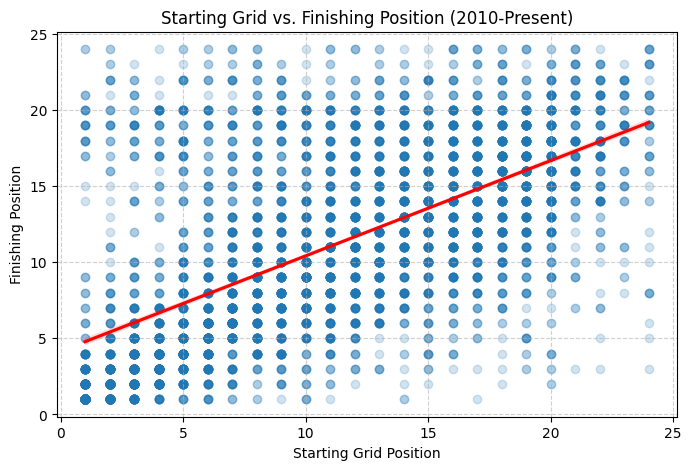

In [3]:
# Filter for modern era (e.g., 2010+) to account for modern reliability/rules
data_modern = data[data['year'] >= 2010].copy()

# Clean grid position (exclude pitlane/unassigned grid 0)
data_clean = data_modern[data_modern['grid'] > 0].copy()

# Ensure types are numeric
X_data = data_clean[['grid']]
y_data = data_clean['positionOrder']

print(f"Dataset size after cleaning: {len(data_clean)} rows")
print("\nCorrelation between Grid and Finish Position:")
print(data_clean[['grid', 'positionOrder']].corr())

# Quick Visualization
plt.figure(figsize=(8, 5))
sns.regplot(data=data_clean, x='grid', y='positionOrder', scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
plt.title('Starting Grid vs. Finishing Position (2010-Present)')
plt.xlabel('Starting Grid Position')
plt.ylabel('Finishing Position')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Necessary EDA Steps**

Before fitting the linear regression model:

1. **Remove Pit Lane Starts / Unassigned Grids:** Filter out `grid == 0` (cars starting from pit lane or unclassified qualifying).
2. **Handle Non-Finishers (DNFs):** Decide whether to evaluate all starters or only drivers who completed the race (`statusId == 1` or classified finishes). `positionOrder` provides total race classification ordering even for late DNFs.
3. **Filter Era:** Focus on modern hybrid era data (e.g., 2014 onwards) or post-2010 where modern safety cars and regulations keep the grid dynamics consistent.
4. **Check Correlation & Outliers:** Plot `grid` vs. `positionOrder` to observe the linear relationship strength and identify heavy outlier points (e.g., driver starting P20 and winning after multiple safety cars).

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [5]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Model Performance ---")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} positions")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} positions")


--- Model Performance ---
R² Score: 0.4152
Mean Absolute Error (MAE): 3.62 positions
Root Mean Squared Error (RMSE): 4.66 positions


In [6]:
slope = model.coef_[0]
intercept = model.intercept_

print("\n--- Model Equation ---")
print(f"Predicted Position = {intercept:.2f} + ({slope:.2f} * Starting Grid)")


--- Model Equation ---
Predicted Position = 4.22 + (0.62 * Starting Grid)


## **Metric Breakdown**

* **$R^2$ Score (0.4152):** Grid position carries significant predictive weight, but ~58.5% of the outcome is governed by factors left out of this simple line (pit strategy, mechanical DNFs, driver pace, safety cars, and track layout).
* **MAE (3.62 positions):** On average, the linear baseline misjudges a driver's final classification by about **3.6 places**.
* **RMSE (4.66 positions):** The notable gap between MAE (3.62) and RMSE (4.66) points to **large outlier events**. When a front-runner suffers a mechanical failure or crashes out (finishing P18–P20 after starting P1), the squared error penalty heavily inflates RMSE.

## **3 Quick Ways to Boost This Model**

If we want to reduce that MAE closer to $\sim 2.5$ positions, the next logical steps involve feature engineering :

1. **Circuit Categorization / Overtaking Difficulty:**
* Monaco has low overtaking capability (high grid-to-finish correlation), whereas Spa or Monza allow frequent passing. Adding `circuitId` as a categorical feature (or target encoding it with average overtaking deltas) will capture track characteristics.


2. **Constructor/Driver Baseline Strength:**
* A Red Bull starting P15 often finishes P2, while a lower-tier team starting P8 might drop to P14. Including `constructorId` or driver standings points before the race introduces car performance capability into the equation.


3. **DNF Flag / Status Filtering:**
* Filtering out rows where `statusId` indicates collision, engine failure, or hydraulics failure ensures the model trains exclusively on completed race pace rather than bad luck events.

In [7]:
# Load metadata files
constructors = pd.read_csv(DATA_DIR + 'constructors.csv')
status = pd.read_csv(DATA_DIR + 'status.csv')

# 1. Start from data_modern and merge circuitId + constructor info + status
data_boosted = data_modern[data_modern['grid'] > 0].copy()

# Ensure race metadata contains circuitId
data_boosted = data_boosted.merge(races[['raceId', 'circuitId']], on='raceId', how='left')

# Merge constructor metadata
data_boosted = data_boosted.merge(
    constructors[['constructorId', 'name']], 
    on='constructorId', 
    suffixes=('', '_constructor')
)

# Merge status metadata
data_boosted = data_boosted.merge(status, on='statusId', how='left')

# 2. Filter out mechanical/accident DNFs (keep classified finishers)
clean_statuses = ['Finished', '+1 Lap', '+2 Laps', '+3 Laps', '+4 Laps', '+5 Laps']
data_boosted = data_boosted[data_boosted['status'].isin(clean_statuses)].copy()

# 3. Engineer Feature: Track-level Grid Correlation (Proxy for Overtaking Difficulty)
def get_grid_corr(group):
    if len(group) > 10:
        corr = group['grid'].corr(group['positionOrder'])
        return corr if not np.isnan(corr) else 0.5
    return 0.5

circuit_grid_corr = (
    data_boosted.groupby('circuitId', group_keys=False)
    .apply(get_grid_corr)
    .reset_index(name='circuit_grid_importance')
)

data_boosted = data_boosted.merge(circuit_grid_corr, on='circuitId', how='left')

# 4. Engineer Feature: Team Strength (One-Hot Encoded Top Constructors vs Rest)
top_constructors = ['Red Bull', 'Mercedes', 'Ferrari', 'McLaren']
for team in top_constructors:
    data_boosted[f'is_{team.lower().replace(" ", "_")}'] = (data_boosted['name_constructor'] == team).astype(int)

/tmp/ipykernel_16/1094657168.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_grid_corr)


In [8]:
# 5. Select Feature Matrix (X) and Target (y)
features = [
    'grid', 
    'circuit_grid_importance',
    'is_red_bull', 
    'is_mercedes', 
    'is_ferrari', 
    'is_mclaren'
]

X_boosted = data_boosted[features].fillna(0)
y_boosted = data_boosted['positionOrder']

print(f"Cleaned dataset rows for boosted training: {len(data_boosted)}")
print(f"Features included: {features}")

Cleaned dataset rows for boosted training: 5211
Features included: ['grid', 'circuit_grid_importance', 'is_red_bull', 'is_mercedes', 'is_ferrari', 'is_mclaren']


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Train / Test Split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_boosted, y_boosted, test_size=0.2, random_state=42
)

# Pipeline: Standardize Features -> Ridge Regression
boosted_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=10.0))
])

boosted_pipeline.fit(X_train_b, y_train_b)

# Predictions
y_pred_boosted = boosted_pipeline.predict(X_test_b)

In [10]:
# Metrics Calculation
r2_b = r2_score(y_test_b, y_pred_boosted)
mae_b = mean_absolute_error(y_test_b, y_pred_boosted)
rmse_b = np.sqrt(mean_squared_error(y_test_b, y_pred_boosted))

print("       BOOSTED MODEL PERFORMANCE         ")
print("==========================================")
print(f"R² Score:                       {r2_b:.4f}  (Baseline: 0.4152)")
print(f"Mean Absolute Error (MAE):      {mae_b:.2f} positions  (Baseline: 3.62)")
print(f"Root Mean Squared Error (RMSE): {rmse_b:.2f} positions  (Baseline: 4.66)")
print("==========================================")

# Inspect Feature Importance / Coefficients
coefficients = boosted_pipeline.named_steps['regressor'].coef_
coef_df = pd.DataFrame({
    'Feature': features,
    'Standardized Coefficient': coefficients
}).sort_values(by='Standardized Coefficient')

print("\n--- Feature Impact Overview ---")
print(coef_df.to_string(index=False))

       BOOSTED MODEL PERFORMANCE         
R² Score:                       0.6341  (Baseline: 0.4152)
Mean Absolute Error (MAE):      2.43 positions  (Baseline: 3.62)
Root Mean Squared Error (RMSE): 3.16 positions  (Baseline: 4.66)

--- Feature Impact Overview ---
                Feature  Standardized Coefficient
            is_red_bull                 -1.067116
            is_mercedes                 -0.955742
             is_ferrari                 -0.866048
             is_mclaren                 -0.515413
circuit_grid_importance                  0.028856
                   grid                  3.213342


### **Next Steps (If you want to push it further)**

If you wanted to squeeze out even more performance, the next logical additions would be:

* **Driver Form / Rolling Average:** A rolling average of the driver's last 3 finish positions to capture current momentum or driver-specific skill.
* **Interaction Terms:** $grid \times circuit\_grid\_importance$ to let grid position penalty scale non-linearly depending on the circuit.
* **Non-Linear Models:** Moving from Ridge Regression to LightGBM / XGBoost to capture non-linear team dynamics and complex track-driver interactions.